In [4]:
import pandas as pd
import numpy as np
import glob
import os
from pathlib import Path
import matplotlib.pyplot as plt
import pandas as pd
import os
import seaborn as sns

sns.set_style("whitegrid")

In [6]:
DATA_DIR = Path("../data/eye_tracking")

In [31]:
csv_files = sorted(DATA_DIR.glob("*.csv"))
print(csv_files[:3])

[PosixPath('../data/eye_tracking/01_ET_Data_2026-02-19.csv'), PosixPath('../data/eye_tracking/02_ET_Data_2026-03-10.csv')]


In [32]:
file_path = csv_files[1]  # Christian on-boarding

df = pd.read_csv(file_path, low_memory=False)

# extract participant_id from filename
participant_id = file_path.name[:2]
df["participant_id"] = participant_id

print(df.shape)

(384510, 61)


In [33]:
def cleaning_function(df: pd.DataFrame) -> pd.DataFrame:
    """
    Preprocess eye-tracking data for analysis.

    Steps:

       - remove training models (TM) and NaN
 ......
    """

    df = df.copy()

    mask = (
        df["model_name"].notna() &
        (~df["model_name"].str.contains("TM", na=False))
    )
    df = df.loc[mask].copy()


    return df

In [34]:
df_clean = cleaning_function(df)

In [35]:
def add_time_per_model(df, time_col: str = "gaze_capture_time"):
    """
    Add time_ms per model_name, respecting experiment order.

    Sorting:
    condition_number → trial_number → time

    Assumes:
    - time_col is in nanoseconds
    - df contains: model_name, condition_number, trial_number
    """

    df = df.copy()

    # correct ordering of experiment
    df = df.sort_values(["condition_number", "trial_number", time_col])

    # compute relative time per model
    t0 = df.groupby("model_name")[time_col].transform("first")

    df["time_ms"] = (df[time_col] - t0) / 1_000_000.0

    return df

In [36]:
df_clean = add_time_per_model(df_clean, time_col="gaze_capture_time")

In [37]:
df_clean

,gaze_capture_time,raw_timestamp,relative_to_unix_epoch_timestamp,focus_distance,frame_number,stability,status,gaze_forward_x,gaze_forward_y,gaze_forward_z,...,model_visibility_state,object_position_x,object_position_y,object_position_z,object_rotation_x,object_rotation_y,object_rotation_z,object_rotation_w,participant_id,time_ms
44844,1000325694741666500,1773141240816,336.4777,0.975025,584492,0.821958,Valid,0.013115,0.144055,0.989483,...,0,3.25,1.520,-0.11,0.0,-0.707107,0.0,0.707107,02,0.0000
44845,1000325694746666700,1773141240816,336.4777,0.977628,584493,0.817059,Valid,0.013078,0.144172,0.989466,...,0,3.25,1.520,-0.11,0.0,-0.707107,0.0,0.707107,02,5.0002
44846,1000325694751663700,1773141240816,336.4777,0.980051,584494,0.827888,Valid,0.013039,0.144279,0.989451,...,0,3.25,1.520,-0.11,0.0,-0.707107,0.0,0.707107,02,9.9972
44847,1000325694756664500,1773141240816,336.4777,0.982777,584495,0.820999,Valid,0.013003,0.144336,0.989443,...,0,3.25,1.520,-0.11,0.0,-0.707107,0.0,0.707107,02,14.9980
44848,1000325694761666200,1773141240824,336.4866,0.985244,584496,0.822582,Valid,0.012964,0.144379,0.989437,...,0,3.25,1.520,-0.11,0.0,-0.707107,0.0,0.707107,02,19.9997
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
381611,1000328169625686100,1773143715702,1593.0000,0.677271,1079278,0.281021,Valid,0.285666,-0.076886,0.955240,...,0,0.75,0.975,-0.70,0.0,0.000000,0.0,1.000000,02,97592.3892
381612,1000328169630684400,1773143715702,1593.0000,0.681785,1079279,0.310471,Valid,0.287534,-0.074987,0.954831,...,0,0.75,0.975,-0.70,0.0,0.000000,0.0,1.000000,02,97597.3875
381613,1000328169635683800,1773143715702,1593.0000,0.681963,1079280,0.328037,Valid,0.288786,-0.073097,0.954599,...,0,0.75,0.975,-0.70,0.0,0.000000,0.0,1.000000,02,97602.3869
381614,1000328169640683200,1773143715702,1593.0000,0.681368,1079281,0.382888,Valid,0.289915,-0.071516,0.954377,...,0,0.75,0.975,-0.70,0.0,0.000000,0.0,1.000000,02,97607.3863


In [38]:
FORWARD_COLS = ["gaze_forward_x", "gaze_forward_y", "gaze_forward_z"]
CLEAN_FORWARD_COLS = ["clean_gaze_forward_x", "clean_gaze_forward_y", "clean_gaze_forward_z"]


def good_status(left_status: pd.Series, right_status: pd.Series) -> np.ndarray:
    l = left_status.astype(str).str.lower().str.strip()
    r = right_status.astype(str).str.lower().str.strip()

    allowed_pairs = {
        ("tracked", "tracked"),
        ("tracked", "compensated"),
        ("compensated", "tracked"),
        ("compensated", "compensated")
    }

    good = pd.Series(
        [(ls, rs) in allowed_pairs for ls, rs in zip(l, r)],
        index=left_status.index
    )

    return good.to_numpy(dtype=bool)

def find_runs(mask: np.ndarray):
    mask = np.asarray(mask, dtype=bool)
    idx = np.flatnonzero(mask)

    if len(idx) == 0:
        return []

    runs = []
    start = prev = idx[0]

    for k in idx[1:]:
        if k == prev + 1:
            prev = k
        else:
            runs.append((start, prev))
            start = prev = k

    runs.append((start, prev))
    return runs

def expand_runs(runs, n, pad=2):
    """
    Expand each run by `pad` samples on both sides,
    then merge overlaps.
    """
    if len(runs) == 0:
        return []

    expanded = []
    for a, b in runs:
        aa = max(0, a - pad)
        bb = min(n - 1, b + pad)
        expanded.append((aa, bb))

    expanded.sort()
    merged = [expanded[0]]

    for a, b in expanded[1:]:
        prev_a, prev_b = merged[-1]
        if a <= prev_b + 1:
            merged[-1] = (prev_a, max(prev_b, b))
        else:
            merged.append((a, b))

    return merged


def normalize_xyz(xyz: np.ndarray) -> np.ndarray:
    xyz = np.asarray(xyz, dtype=float)
    nrm = np.linalg.norm(xyz, axis=1)
    out = np.full_like(xyz, np.nan, dtype=float)
    good = np.isfinite(nrm) & (nrm > 1e-8) & np.all(np.isfinite(xyz), axis=1)
    out[good] = xyz[good] / nrm[good, None]
    return out


def interpolate_segment(sub: pd.DataFrame, forward_cols=FORWARD_COLS, pad: int = 2) -> pd.DataFrame:
    sub = sub.sort_values("time_ms").copy()
    t = sub["time_ms"].to_numpy(dtype=float)

    xyz = np.column_stack([
        pd.to_numeric(sub[c], errors="coerce").to_numpy(dtype=float)
        for c in forward_cols
    ])

    good = good_status(sub["left_status"], sub["right_status"])
    bad = ~good
    bad_runs = find_runs(bad)

    n = len(sub)
    is_interpolated = np.zeros(n, dtype=bool)

    clean = xyz.copy()

    # expand bad runs by buffer
    buffered_runs = expand_runs(bad_runs, n=n, pad=pad)

    # set buffered regions to NaN before interpolation
    for a, b in buffered_runs:
        clean[a:b+1, :] = np.nan

    for a, b in buffered_runs:
        left = a - 1
        right = b + 1

        bracketed = (
            left >= 0 and
            right < n and
            np.all(np.isfinite(xyz[left])) and
            np.all(np.isfinite(xyz[right]))
        )

        if bracketed:
            for dim in range(3):
                clean[a:b+1, dim] = np.interp(
                    t[a:b+1],
                    [t[left], t[right]],
                    [xyz[left, dim], xyz[right, dim]]
                )

            clean[a:b+1, :] = normalize_xyz(clean[a:b+1, :])
            is_interpolated[a:b+1] = True

    sub["good_sample"] = good
    sub["bad_sample"] = bad
    sub["is_interpolated"] = is_interpolated

    for j, c in enumerate(forward_cols):
        sub[f"clean_{c}"] = clean[:, j]

    return sub


def interpolate_all_segments(df: pd.DataFrame, pad: int = 2) -> pd.DataFrame:
    out = []

    for (cond, trial), sub in df.groupby(["condition_number", "trial_number"], sort=True):
        cleaned = interpolate_segment(sub, forward_cols=FORWARD_COLS, pad=pad)
        cleaned["segment_label"] = f"C{int(cond)}_T{int(trial)}"
        out.append(cleaned)

    return (
        pd.concat(out, axis=0)
        .sort_values(["condition_number", "trial_number", "time_ms"])
        .reset_index(drop=True)
    )

In [39]:
df_clean = interpolate_all_segments(df_clean)

In [40]:
def median_filter_valid_runs(x: pd.Series, window: int = 5) -> pd.Series:
    y = x.to_numpy(dtype=float).copy()
    out = y.copy()

    valid = np.isfinite(y)
    idx = np.flatnonzero(valid)

    if len(idx) == 0:
        return pd.Series(out, index=x.index)

    runs = []
    start = prev = idx[0]

    for k in idx[1:]:
        if k == prev + 1:
            prev = k
        else:
            runs.append((start, prev))
            start = prev = k
    runs.append((start, prev))

    for a, b in runs:
        seg = pd.Series(y[a:b+1])

        # centered 5-point median, allowing shorter windows at edges
        filt = seg.rolling(window=window, center=True, min_periods=1).median()

        out[a:b+1] = filt.to_numpy()

    return pd.Series(out, index=x.index)

WINDOW = 5

for col in CLEAN_FORWARD_COLS:
    df_clean[col] = (
        df_clean.groupby(["condition_number", "trial_number"])[col]
        .transform(lambda x: median_filter_valid_runs(x, window=WINDOW))
    )

# renormalize after median filtering
xyz = df_clean[CLEAN_FORWARD_COLS].to_numpy(dtype=float)
df_clean[CLEAN_FORWARD_COLS] = normalize_xyz(xyz)

In [41]:
# 7) QUALITY-CONTROL SUMMARY
qc = (
    df_clean.groupby(["condition_number", "trial_number"])
    .agg(
        n_samples=("time_ms", "size"),
        n_bad=("bad_sample", "sum"),
        n_interpolated=("is_interpolated", "sum"),
    )
    .reset_index()
)

# percentages
qc["pct_bad"] = 100 * qc["n_bad"] / qc["n_samples"]
qc["pct_interpolated"] = 100 * qc["n_interpolated"] / qc["n_samples"]

print(qc.to_string(index=False))

 condition_number  trial_number  n_samples  n_bad  n_interpolated  pct_bad  pct_interpolated
                1             1       4001    215             270 5.373657          6.748313
                1             2      21653    408             540 1.884265          2.493881
                1             3      10276    221             303 2.150642          2.948618
                1             4      12824    337             449 2.627885          3.501248
                1             5       4651    153             201 3.289615          4.321651
                1             6      15074    447             549 2.965371          3.642033
                2             1      10647    263             315 2.470179          2.958580
                2             2       3546     83             117 2.340666          3.299492
                2             3      18793   1402            1530 7.460225          8.141329
                2             4       3706    125             155 3.37

In [42]:
def add_angular_velocity(df, time_col="gaze_capture_time"):
    """
    Compute gaze angular velocity (deg/s) from Varjo gaze_forward vectors.

    Method
    ------
    1. Take consecutive 3D gaze direction vectors.
    2. Compute the angle between them with:
           angle = atan2(||g_prev x g_curr||, g_prev · g_curr)
       This is numerically stable.
    3. Divide by the time difference in seconds.
    4. Convert from rad/s to deg/s.

    Assumptions
    -----------
    - gaze_forward_x/y/z describe gaze direction.
    - time_col is in nanoseconds.
    - Velocity should be computed within each participant/model block.

    Returns
    -------
    df : copy of input dataframe with a new column:
         - angular_velocity
    """
    df = df.copy()

    # Sort so consecutive rows are truly consecutive in time
    df = df.sort_values(
        ["condition_number", "trial_number", time_col]
    )

    # Initialize output column
    df["angular_velocity"] = np.nan

    # Compute separately within each continuous block
    for (_, _), sub in df.groupby(["condition_number", "trial_number"], sort=False):
        idx = sub.index

        # Extract gaze direction vectors
        g = sub[[
            "clean_gaze_forward_x",
            "clean_gaze_forward_y",
            "clean_gaze_forward_z"
        ]].to_numpy(dtype=float)

        # Normalize vectors just in case they are not perfectly unit length
        norms = np.linalg.norm(g, axis=1, keepdims=True)
        g = g / np.clip(norms, 1e-12, None)

        # Previous and current vectors
        g_prev = g[:-1]
        g_curr = g[1:]

        # Angle between consecutive vectors:
        # angle = atan2(||cross||, dot)
        cross_norm = np.linalg.norm(np.cross(g_prev, g_curr), axis=1)
        dot_prod = np.sum(g_prev * g_curr, axis=1)
        angles_rad = np.arctan2(cross_norm, dot_prod)

        # Time difference in seconds (timestamps are in nanoseconds)
        t = sub[time_col].to_numpy(dtype=np.int64)
        dt = np.diff(t) * 1e-9

        # Prepare output for this block
        vel = np.full(len(sub), np.nan)

        # Only compute where dt is valid
        valid = dt > 0
        vel[1:][valid] = np.degrees(angles_rad[valid] / dt[valid])

        # Write back into dataframe
        df.loc[idx, "angular_velocity"] = vel

    return df

In [43]:
df_clean = add_angular_velocity(df_clean, time_col="gaze_capture_time")

In [44]:
def at_mad_threshold(angular_vel, th_0=200.0, min_samples=10, tol=1.0, max_iter=50):
    """
    Compute one adaptive saccade threshold from angular velocity using MAD.

    Parameters
    ----------
    angular_vel : array-like
        Angular velocity values in deg/s.
    th_0 : float, default=200.0
        Initial threshold in deg/s.
    min_samples : int, default=10
        Minimum number of valid samples required.
    tol : float, default=1.0
        Convergence tolerance in deg/s.
    max_iter : int, default=50
        Maximum number of iterations.

    Returns
    -------
    saccade_thresh : float
        Final threshold in deg/s.
    threshs : list[float]
        Threshold values across iterations.
    """
    v = pd.to_numeric(pd.Series(angular_vel), errors="coerce").to_numpy(dtype=float)
    v = v[np.isfinite(v)]

    if len(v) < min_samples:
        return np.nan, []

    threshs = []
    current_th = float(th_0)

    for _ in range(max_iter):
        threshs.append(current_th)

        subset = v[v < current_th]
        subset = subset[np.isfinite(subset)]

        if len(subset) < min_samples:
            return np.nan, threshs

        median = np.median(subset)
        mad = np.median(np.abs(subset - median))
        next_th = median + 3.0 * 1.486 * mad

        if not np.isfinite(next_th):
            return np.nan, threshs

        if abs(current_th - next_th) <= tol:
            threshs.append(float(next_th))
            return float(next_th), threshs

        current_th = float(next_th)

    return float(current_th), threshs


def compute_global_mad_threshold(
    df,
    vel_col="angular_velocity",
    th_0=200.0,
    min_samples=10,
    tol=1.0,
    max_iter=50,
):
    """
    Compute one MAD-based threshold across all trials, conditions, and rows.

    Returns
    -------
    threshold : float
        Global angular velocity threshold.
    summary_df : pd.DataFrame
        One-row summary table for reporting/saving.
    """
    threshold, trace = at_mad_threshold(
        df[vel_col],
        th_0=th_0,
        min_samples=min_samples,
        tol=tol,
        max_iter=max_iter,
    )

    n_valid = pd.to_numeric(df[vel_col], errors="coerce").notna().sum()

    summary_df = pd.DataFrame(
        {
            "mad_threshold": [threshold],
            "n_valid_velocity_samples": [int(n_valid)],
            "threshold_trace": [trace],
        }
    )

    return threshold, summary_df


def add_global_mad_threshold(df, threshold, threshold_col="mad_threshold"):
    """
    Add the same global threshold to every row.
    """
    df = df.copy()
    df[threshold_col] = threshold
    return df


In [45]:
global_threshold, threshold_summary = compute_global_mad_threshold(df_clean)

In [46]:
df_clean = add_global_mad_threshold(df_clean, global_threshold)

In [47]:
print("Global MAD threshold:", global_threshold)

Global MAD threshold: 35.04128224525182


In [1]:
threshold_summary

NameError: name 'threshold_summary' is not defined

In [50]:
df_clean

,gaze_capture_time,raw_timestamp,relative_to_unix_epoch_timestamp,focus_distance,frame_number,stability,status,gaze_forward_x,gaze_forward_y,gaze_forward_z,...,good_sample,bad_sample,is_interpolated,clean_gaze_forward_x,clean_gaze_forward_y,clean_gaze_forward_z,segment_label,angular_velocity,mad_threshold,velocity_category
0,1000325694741666500,1773141240816,336.4777,0.975025,584492,0.821958,Valid,0.013115,0.144055,0.989483,...,True,False,False,0.013078,0.144172,0.989466,C1_T1,NaN,35.041282,<NA>
1,1000325694746666700,1773141240816,336.4777,0.977628,584493,0.817059,Valid,0.013078,0.144172,0.989466,...,True,False,False,0.013059,0.144225,0.989459,C1_T1,0.653459,35.041282,fixation
2,1000325694751663700,1773141240816,336.4777,0.980051,584494,0.827888,Valid,0.013039,0.144279,0.989451,...,True,False,False,0.013039,0.144279,0.989451,C1_T1,0.653878,35.041282,fixation
3,1000325694756664500,1773141240816,336.4777,0.982777,584495,0.820999,Valid,0.013003,0.144336,0.989443,...,True,False,False,0.013003,0.144336,0.989443,C1_T1,0.791661,35.041282,fixation
4,1000325694761666200,1773141240824,336.4866,0.985244,584496,0.822582,Valid,0.012964,0.144379,0.989437,...,True,False,False,0.012964,0.144336,0.989444,C1_T1,0.443740,35.041282,fixation
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
202964,1000328169625686100,1773143715702,1593.0000,0.677271,1079278,0.281021,Valid,0.285666,-0.076886,0.955240,...,True,False,False,0.285666,-0.076886,0.955240,C3_T6,37.569699,35.041282,saccade
202965,1000328169630684400,1773143715702,1593.0000,0.681785,1079279,0.310471,Valid,0.287534,-0.074987,0.954831,...,True,False,False,0.287534,-0.074987,0.954830,C3_T6,30.886675,35.041282,fixation
202966,1000328169635683800,1773143715702,1593.0000,0.681963,1079280,0.328037,Valid,0.288786,-0.073097,0.954599,...,True,False,False,0.288786,-0.073097,0.954599,C3_T6,26.124483,35.041282,fixation
202967,1000328169640683200,1773143715702,1593.0000,0.681368,1079281,0.382888,Valid,0.289915,-0.071516,0.954377,...,True,False,False,0.289351,-0.072306,0.954488,C3_T6,11.203345,35.041282,fixation


In [49]:
def add_velocity_category(
    df,
    vel_col="angular_velocity",
    threshold_col="mad_threshold",
    category_col="velocity_category",
):
    """
    Label each sample as fixation or saccade using angular velocity and MAD threshold.

    Rules
    -----
    - fixation: angular_velocity < mad_threshold
    - saccade:  angular_velocity >= mad_threshold
    - NaN:      if angular_velocity or mad_threshold is missing
    """
    df = df.copy()

    vel = pd.to_numeric(df[vel_col], errors="coerce")
    thr = pd.to_numeric(df[threshold_col], errors="coerce")

    df[category_col] = pd.Series(pd.NA, index=df.index, dtype="string")

    valid = vel.notna() & thr.notna()
    df.loc[valid & (vel < thr), category_col] = "fixation"
    df.loc[valid & (vel >= thr), category_col] = "saccade"

    return df


In [50]:
df_clean = add_velocity_category(df_clean)

In [53]:
df_clean

,gaze_capture_time,raw_timestamp,relative_to_unix_epoch_timestamp,focus_distance,frame_number,stability,status,gaze_forward_x,gaze_forward_y,gaze_forward_z,...,good_sample,bad_sample,is_interpolated,clean_gaze_forward_x,clean_gaze_forward_y,clean_gaze_forward_z,segment_label,angular_velocity,mad_threshold,velocity_category
0,1000325694741666500,1773141240816,336.4777,0.975025,584492,0.821958,Valid,0.013115,0.144055,0.989483,...,True,False,False,0.013078,0.144172,0.989466,C1_T1,NaN,35.041282,<NA>
1,1000325694746666700,1773141240816,336.4777,0.977628,584493,0.817059,Valid,0.013078,0.144172,0.989466,...,True,False,False,0.013059,0.144225,0.989459,C1_T1,0.653459,35.041282,fixation
2,1000325694751663700,1773141240816,336.4777,0.980051,584494,0.827888,Valid,0.013039,0.144279,0.989451,...,True,False,False,0.013039,0.144279,0.989451,C1_T1,0.653878,35.041282,fixation
3,1000325694756664500,1773141240816,336.4777,0.982777,584495,0.820999,Valid,0.013003,0.144336,0.989443,...,True,False,False,0.013003,0.144336,0.989443,C1_T1,0.791661,35.041282,fixation
4,1000325694761666200,1773141240824,336.4866,0.985244,584496,0.822582,Valid,0.012964,0.144379,0.989437,...,True,False,False,0.012964,0.144336,0.989444,C1_T1,0.443740,35.041282,fixation
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
202964,1000328169625686100,1773143715702,1593.0000,0.677271,1079278,0.281021,Valid,0.285666,-0.076886,0.955240,...,True,False,False,0.285666,-0.076886,0.955240,C3_T6,37.569699,35.041282,saccade
202965,1000328169630684400,1773143715702,1593.0000,0.681785,1079279,0.310471,Valid,0.287534,-0.074987,0.954831,...,True,False,False,0.287534,-0.074987,0.954830,C3_T6,30.886675,35.041282,fixation
202966,1000328169635683800,1773143715702,1593.0000,0.681963,1079280,0.328037,Valid,0.288786,-0.073097,0.954599,...,True,False,False,0.288786,-0.073097,0.954599,C3_T6,26.124483,35.041282,fixation
202967,1000328169640683200,1773143715702,1593.0000,0.681368,1079281,0.382888,Valid,0.289915,-0.071516,0.954377,...,True,False,False,0.289351,-0.072306,0.954488,C3_T6,11.203345,35.041282,fixation


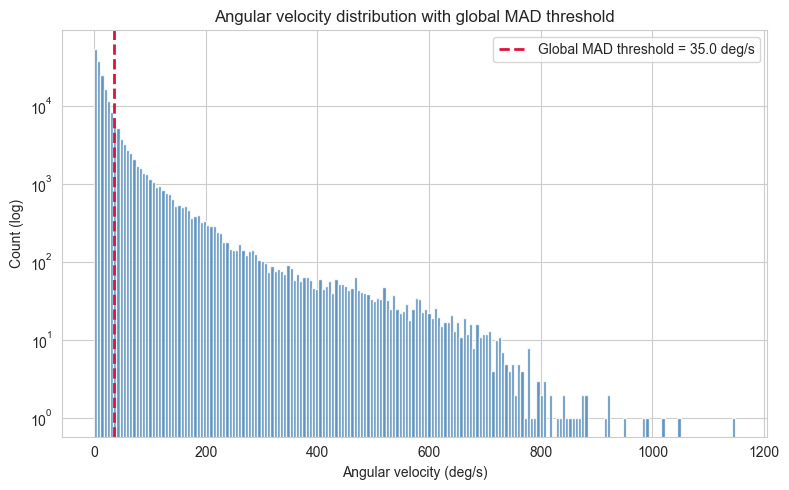

In [24]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

vel = pd.to_numeric(df_clean["angular_velocity"], errors="coerce")
vel = vel[np.isfinite(vel)]

global_mad_threshold, global_trace = at_mad_threshold(vel, th_0=200.0)

plt.figure(figsize=(8, 5))
plt.hist(vel, bins=200, color="steelblue", alpha=0.85)
plt.yscale("log")

plt.axvline(
    global_mad_threshold,
    color="crimson",
    linestyle="--",
    linewidth=2,
    label=f"Global MAD threshold = {global_mad_threshold:.1f} deg/s"
)

plt.xlabel("Angular velocity (deg/s)")
plt.ylabel("Count (log)")
plt.title("Angular velocity distribution with global MAD threshold")
plt.legend()
plt.tight_layout()
plt.show()


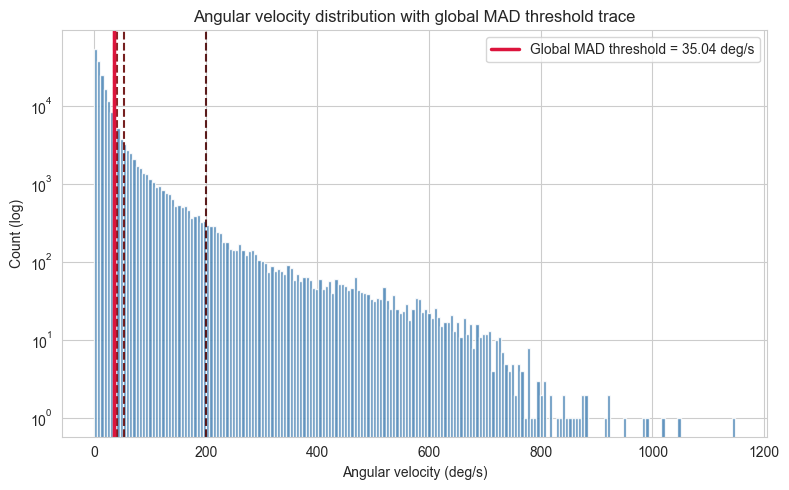

In [26]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap

vel = pd.to_numeric(df_clean["angular_velocity"], errors="coerce")
vel = vel[np.isfinite(vel)]

global_mad_threshold, global_trace = at_mad_threshold(vel, th_0=200.0)

plt.figure(figsize=(8, 5))
plt.hist(vel, bins=200, color="steelblue", alpha=0.85)
plt.yscale("log")

# dark red -> bright red
red_grad = LinearSegmentedColormap.from_list(
    "mad_red_grad",
    ["#4a0404", "#7a0a0a", "#b11226", "#ff4d5a"]
)

n = len(global_trace)

for j, thr in enumerate(global_trace):
    frac = j / max(n - 1, 1)
    color = red_grad(frac)

    plt.axvline(
        thr,
        color=color,
        linestyle="--",
        linewidth=1.5,
        alpha=0.9
    )

# Final threshold highlighted
plt.axvline(
    global_mad_threshold,
    color="crimson",
    linestyle="-",
    linewidth=2.5,
    label=f"Global MAD threshold = {global_mad_threshold:.2f} deg/s"
)

plt.xlabel("Angular velocity (deg/s)")
plt.ylabel("Count (log)")
plt.title("Angular velocity distribution with global MAD threshold trace")
plt.legend()
plt.tight_layout()
plt.show()


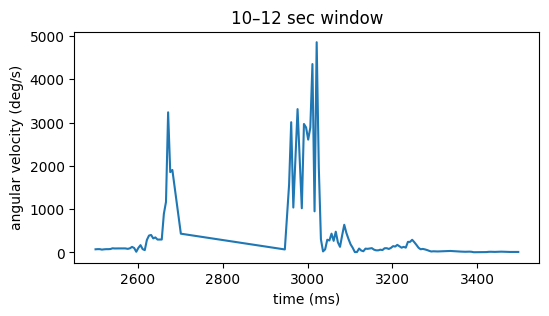

In [17]:
sub = df_clean[
    (df_clean["condition_number"] == 2) &
    (df_clean["trial_number"] == 2) &
    (df_clean["time_ms"] >= 2500) &   # 2.5 sec
    (df_clean["time_ms"] <= 3500)     # 3.5 sec
].copy()

plt.figure(figsize=(6,3))
plt.plot(sub["time_ms"], sub["angular_velocity"])
plt.xlabel("time (ms)")
plt.ylabel("angular velocity (deg/s)")
plt.title("10–12 sec window")
plt.show()

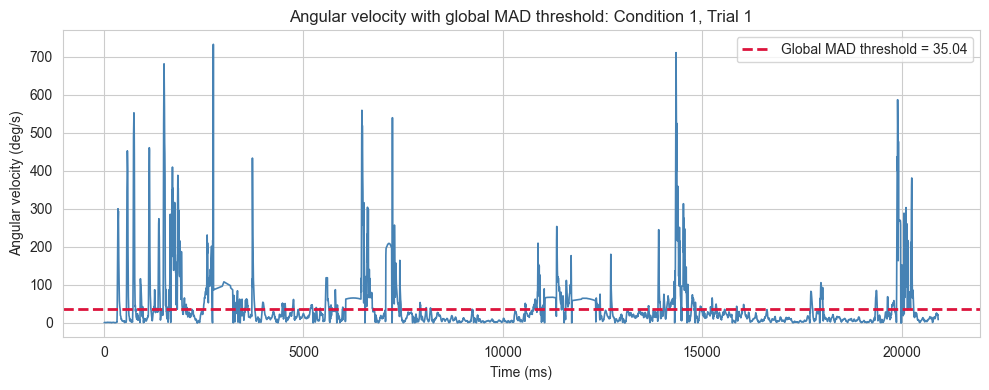

In [54]:

cond = 1
trial = 1

sub = df_clean[
    (df_clean["condition_number"] == cond) &
    (df_clean["trial_number"] == trial)
].copy()

sub["angular_velocity"] = pd.to_numeric(sub["angular_velocity"], errors="coerce")
sub["time_ms"] = pd.to_numeric(sub["time_ms"], errors="coerce")

vel_all = pd.to_numeric(df_clean["angular_velocity"], errors="coerce")
vel_all = vel_all[np.isfinite(vel_all)]

global_mad_threshold, global_trace = at_mad_threshold(vel_all, th_0=200.0)

plt.figure(figsize=(10, 4))
plt.plot(sub["time_ms"], sub["angular_velocity"], lw=1.2, color="steelblue")
plt.axhline(
    global_mad_threshold,
    color="crimson",
    ls="--",
    lw=2,
    label=f"Global MAD threshold = {global_mad_threshold:.2f}"
)

plt.xlabel("Time (ms)")
plt.ylabel("Angular velocity (deg/s)")
plt.title(f"Angular velocity with global MAD threshold: Condition {cond}, Trial {trial}")
plt.legend()
plt.tight_layout()
plt.show()


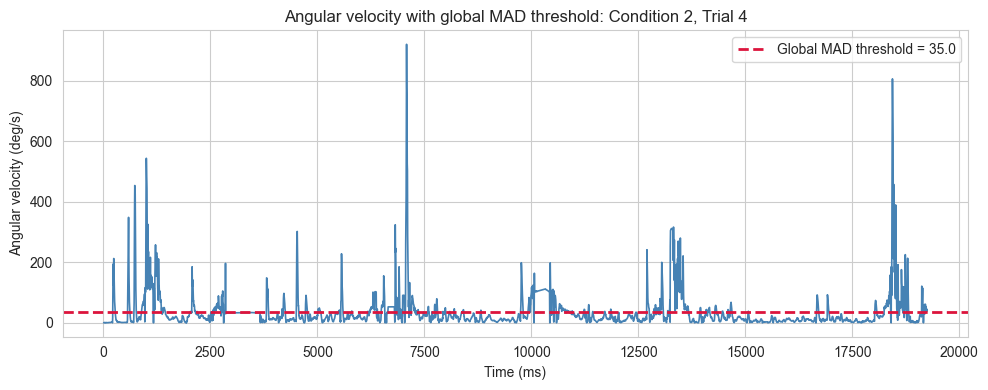

In [58]:

cond = 2
trial = 4

sub = df_clean[
    (df_clean["condition_number"] == cond) &
    (df_clean["trial_number"] == trial)
].copy()

sub["angular_velocity"] = pd.to_numeric(sub["angular_velocity"], errors="coerce")
sub["time_ms"] = pd.to_numeric(sub["time_ms"], errors="coerce")

vel_all = pd.to_numeric(df_clean["angular_velocity"], errors="coerce")
vel_all = vel_all[np.isfinite(vel_all)]

global_mad_threshold, global_trace = at_mad_threshold(vel_all, th_0=200.0)

plt.figure(figsize=(10, 4))
plt.plot(sub["time_ms"], sub["angular_velocity"], lw=1.2, color="steelblue")
plt.axhline(
    global_mad_threshold,
    color="crimson",
    ls="--",
    lw=2,
    label=f"Global MAD threshold = {global_mad_threshold:.1f}"
)

plt.xlabel("Time (ms)")
plt.ylabel("Angular velocity (deg/s)")
plt.title(f"Angular velocity with global MAD threshold: Condition {cond}, Trial {trial}")
plt.legend()
plt.tight_layout()
plt.show()



cond = 3
trial = 4

sub = df_clean[
    (df_clean["condition_number"] == cond) &
    (df_clean["trial_number"] == trial)
].copy()

sub["angular_velocity"] = pd.to_numeric(sub["angular_velocity"], errors="coerce")
sub["time_ms"] = pd.to_numeric(sub["time_ms"], errors="coerce")

vel_all = pd.to_numeric(df_clean["angular_velocity"], errors="coerce")
vel_all = vel_all[np.isfinite(vel_all)]

global_mad_threshold, global_trace = at_mad_threshold(vel_all, th_0=200.0)

plt.figure(figsize=(10, 4))
plt.plot(sub["time_ms"], sub["angular_velocity"], lw=1.2, color="steelblue")
plt.axhline(
    global_mad_threshold,
    color="crimson",
    ls="--",
    lw=2,
    label=f"Global MAD threshold = {global_mad_threshold:.2f}"
)

plt.xlabel("Time (ms)")
plt.ylabel("Angular velocity (deg/s)")
plt.title(f"Angular velocity with global MAD threshold: Condition {cond}, Trial {trial}")
plt.legend()
plt.tight_layout()
plt.show()


In [88]:

df_clean["gaze_forward_x"].min()

np.float64(-0.9084389)

In [89]:
df_clean["gaze_forward_x"].max()


np.float64(0.6763899)

In [83]:
df_clean

,gaze_capture_time,raw_timestamp,relative_to_unix_epoch_timestamp,focus_distance,frame_number,stability,status,gaze_forward_x,gaze_forward_y,gaze_forward_z,...,object_position_x,object_position_y,object_position_z,object_rotation_x,object_rotation_y,object_rotation_z,object_rotation_w,participant_id,time_ms,angular_velocity
44844,1000325694741666500,1773141240816,336.4777,0.975025,584492,0.821958,Valid,0.013115,0.144055,0.989483,...,3.25,1.520,-0.11,0.0,-0.707107,0.0,0.707107,02,0.0000,NaN
44845,1000325694746666700,1773141240816,336.4777,0.977628,584493,0.817059,Valid,0.013078,0.144172,0.989466,...,3.25,1.520,-0.11,0.0,-0.707107,0.0,0.707107,02,5.0002,1.420650
44846,1000325694751663700,1773141240816,336.4777,0.980051,584494,0.827888,Valid,0.013039,0.144279,0.989451,...,3.25,1.520,-0.11,0.0,-0.707107,0.0,0.707107,02,9.9972,1.307756
44847,1000325694756664500,1773141240816,336.4777,0.982777,584495,0.820999,Valid,0.013003,0.144336,0.989443,...,3.25,1.520,-0.11,0.0,-0.707107,0.0,0.707107,02,14.9980,0.791661
44848,1000325694761666200,1773141240824,336.4866,0.985244,584496,0.822582,Valid,0.012964,0.144379,0.989437,...,3.25,1.520,-0.11,0.0,-0.707107,0.0,0.707107,02,19.9997,0.664515
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
381611,1000328169625686100,1773143715702,1593.0000,0.677271,1079278,0.281021,Valid,0.285666,-0.076886,0.955240,...,0.75,0.975,-0.70,0.0,0.000000,0.0,1.000000,02,97592.3892,37.569699
381612,1000328169630684400,1773143715702,1593.0000,0.681785,1079279,0.310471,Valid,0.287534,-0.074987,0.954831,...,0.75,0.975,-0.70,0.0,0.000000,0.0,1.000000,02,97597.3875,30.886675
381613,1000328169635683800,1773143715702,1593.0000,0.681963,1079280,0.328037,Valid,0.288786,-0.073097,0.954599,...,0.75,0.975,-0.70,0.0,0.000000,0.0,1.000000,02,97602.3869,26.124483
381614,1000328169640683200,1773143715702,1593.0000,0.681368,1079281,0.382888,Valid,0.289915,-0.071516,0.954377,...,0.75,0.975,-0.70,0.0,0.000000,0.0,1.000000,02,97607.3863,22.406689


In [43]:
df_clean["angular_velocity"].describe()

count    202951.000000
mean         48.197764
std         170.719307
min           0.009793
25%           5.700849
50%          13.973341
75%          35.573098
max        9431.987025
Name: angular_velocity, dtype: float64

In [44]:
df_clean["angular_velocity"].info()

<class 'pandas.core.series.Series'>
Index: 202969 entries, 44844 to 381615
Series name: angular_velocity
Non-Null Count   Dtype  
--------------   -----  
202951 non-null  float64
dtypes: float64(1)
memory usage: 11.2 MB


## Plot distribution (log scale!)

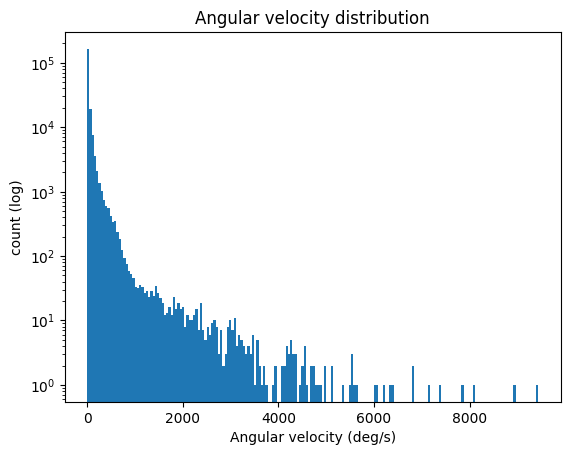

In [84]:
plt.hist(df_clean["angular_velocity"], bins=200)
plt.yscale("log")
plt.xlabel("Angular velocity (deg/s)")
plt.ylabel("count (log)")
plt.title("Angular velocity distribution")
plt.show()

In [91]:
df_clean["angular_velocity"].max()

np.float64(9431.987025217624)

## Time-series Check

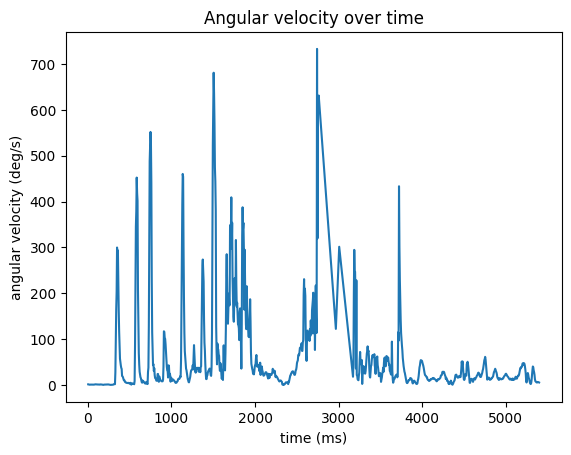

In [85]:
sub = df_clean[df_clean["participant_id"] == "02"].iloc[:1000]

plt.plot(sub["time_ms"], sub["angular_velocity"])
plt.xlabel("time (ms)")
plt.ylabel("angular velocity (deg/s)")
plt.title("Angular velocity over time")
plt.show()

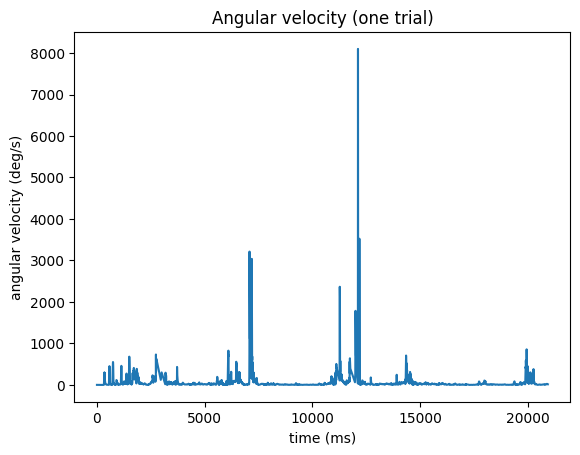

In [92]:
sub = df_clean[
    (df_clean["condition_number"] == 1) &
    (df_clean["trial_number"] == 1)
].copy()

# sort (important!)
sub = sub.sort_values("gaze_capture_time")

plt.plot(sub["time_ms"], sub["angular_velocity"])
plt.xlabel("time (ms)")
plt.ylabel("angular velocity (deg/s)")
plt.title("Angular velocity (one trial)")
plt.show()

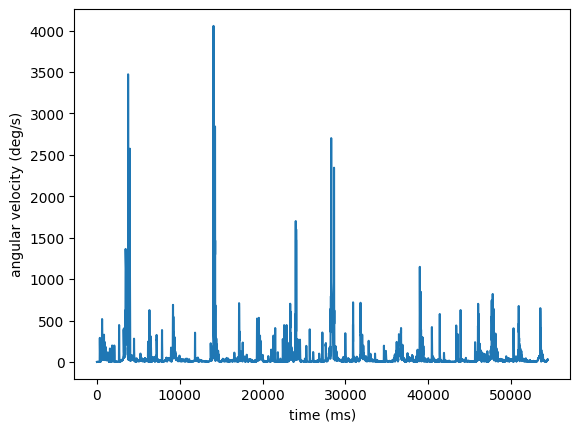

In [48]:
sub = df_clean[
    (df_clean["condition_number"] == 2) &
    (df_clean["trial_number"] == 1)
].copy()

sub = sub.sort_values("gaze_capture_time")

plt.plot(sub["time_ms"], sub["angular_velocity"])
plt.xlabel("time (ms)")
plt.ylabel("angular velocity (deg/s)")
plt.show()

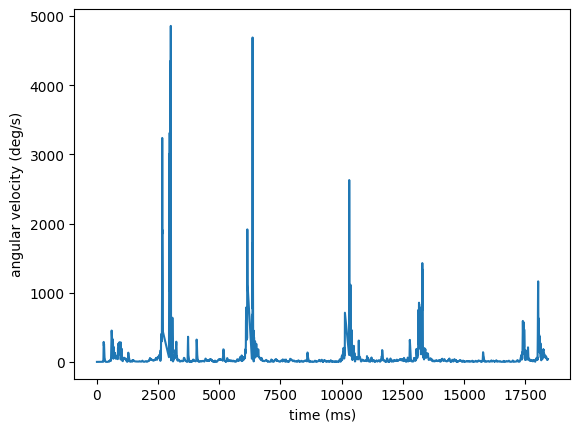

In [49]:
sub = df_clean[
    (df_clean["condition_number"] == 2) &
    (df_clean["trial_number"] == 2)
].copy()

sub = sub.sort_values("gaze_capture_time")

plt.plot(sub["time_ms"], sub["angular_velocity"])
plt.xlabel("time (ms)")
plt.ylabel("angular velocity (deg/s)")
plt.show()

In [50]:
# find extreme points
spikes = sub[sub["angular_velocity"] > 2000]

# pick one spike
i = spikes.index[0]

# take small window around it
window = sub.loc[i-5:i+5].copy()

window[[
    "time_ms",
    "gaze_capture_time",
    "angular_velocity",
    "gaze_forward_x",
    "gaze_forward_y",
    "gaze_forward_z"
]]

,time_ms,gaze_capture_time,angular_velocity,gaze_forward_x,gaze_forward_y,gaze_forward_z
207592,2641.3360,1000326925556781700,347.075613,-0.231893,0.072707,0.970020
207593,2646.3335,1000326925561779200,297.482298,-0.256778,0.068435,0.964044
207594,2656.3347,1000326925571780400,298.347488,-0.280610,0.022355,0.959561
207595,2661.3358,1000326925576781500,891.878701,-0.212975,-0.011985,0.976984
207596,2666.3430,1000326925581788700,1167.716432,-0.113437,-0.027326,0.993169
207597,2671.3436,1000326925586789300,3237.520757,-0.175517,-0.296575,0.938742
207598,2676.3437,1000326925591789400,1855.817741,-0.035894,-0.377197,0.925437
207599,2681.3448,1000326925596790500,1905.876387,0.099029,-0.463240,0.880682
207600,2701.3486,1000326925616794300,433.091101,-0.031565,-0.396767,0.917376
207601,2946.3730,1000326925861818700,68.881033,-0.066556,-0.114849,0.991151


In [51]:
dt = window["gaze_capture_time"].diff() * 1e-9
print(dt)

207592         NaN
207593    0.004998
207594    0.010001
207595    0.005001
207596    0.005007
207597    0.005001
207598    0.005000
207599    0.005001
207600    0.020004
207601    0.245024
207602    0.009997
Name: gaze_capture_time, dtype: float64


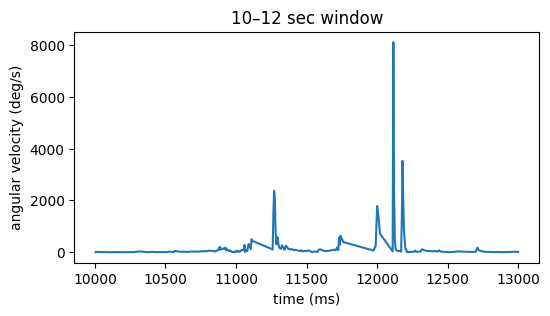

In [54]:
sub = df_clean[
    (df_clean["condition_number"] == 1) &
    (df_clean["trial_number"] == 1) &
    (df_clean["time_ms"] >= 10000) &   # 10 sec
    (df_clean["time_ms"] <= 13000)     # 12 sec
].copy()

plt.figure(figsize=(6,3))
plt.plot(sub["time_ms"], sub["angular_velocity"])
plt.xlabel("time (ms)")
plt.ylabel("angular velocity (deg/s)")
plt.title("10–12 sec window")
plt.show()

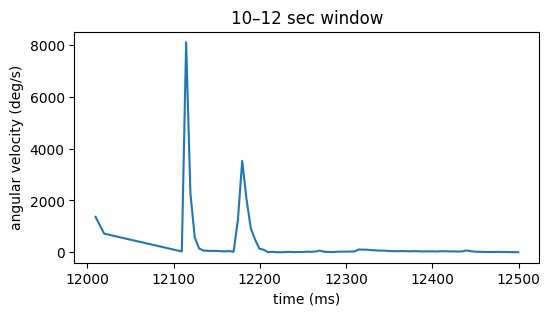

In [55]:
sub = df_clean[
    (df_clean["condition_number"] == 1) &
    (df_clean["trial_number"] == 1) &
    (df_clean["time_ms"] >= 12000) &   # 10 sec
    (df_clean["time_ms"] <= 12500)     # 12 sec
].copy()

plt.figure(figsize=(6,3))
plt.plot(sub["time_ms"], sub["angular_velocity"])
plt.xlabel("time (ms)")
plt.ylabel("angular velocity (deg/s)")
plt.title("10–12 sec window")
plt.show()

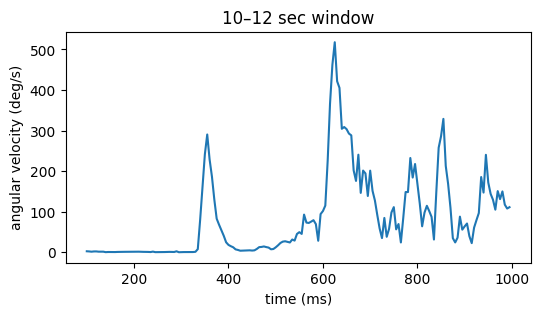

In [63]:
sub = df_clean[
    (df_clean["condition_number"] == 2) &
    (df_clean["trial_number"] == 1) &
    (df_clean["time_ms"] >= 100) &   # 10 sec
    (df_clean["time_ms"] <= 1000)     # 12 sec
].copy()

plt.figure(figsize=(6,3))
plt.plot(sub["time_ms"], sub["angular_velocity"])
plt.xlabel("time (ms)")
plt.ylabel("angular velocity (deg/s)")
plt.title("10–12 sec window")
plt.show()

In [74]:
import numpy as np

df_tmp = df_clean.copy()
df_tmp["clean_norm"] = np.sqrt(
    df_tmp["clean_gaze_forward_x"]**2 +
    df_tmp["clean_gaze_forward_y"]**2 +
    df_tmp["clean_gaze_forward_z"]**2
)

print("Mean norm:", df_tmp["clean_norm"].mean())
print("Min norm:", df_tmp["clean_norm"].min())
print("Max norm:", df_tmp["clean_norm"].max())
print("Max |norm - 1|:", np.abs(df_tmp["clean_norm"] - 1).max())


Mean norm: 1.0
Min norm: 0.9999999999999997
Max norm: 1.0000000000000002
Max |norm - 1|: 3.3306690738754696e-16


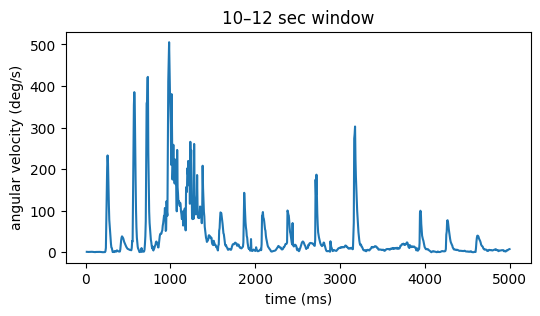

In [68]:
sub = df_clean[
    (df_clean["condition_number"] == 2) &
    (df_clean["trial_number"] == 5) &
    (df_clean["time_ms"] >= 10) &   # 10 sec
    (df_clean["time_ms"] <= 5000)     # 12 sec
].copy()

plt.figure(figsize=(6,3))
plt.plot(sub["time_ms"], sub["angular_velocity"])
plt.xlabel("time (ms)")
plt.ylabel("angular velocity (deg/s)")
plt.title("10–12 sec window")
plt.show()

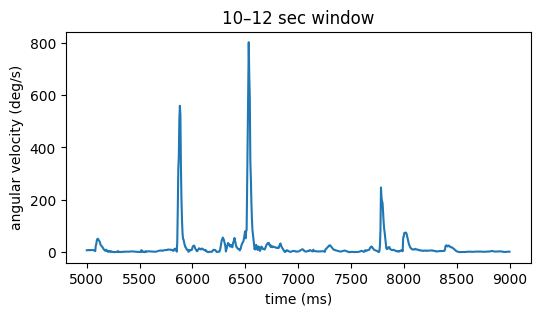

In [69]:
sub = df_clean[
    (df_clean["condition_number"] == 2) &
    (df_clean["trial_number"] == 5) &
    (df_clean["time_ms"] >= 5000) &   # 10 sec
    (df_clean["time_ms"] <= 9000)     # 12 sec
].copy()

plt.figure(figsize=(6,3))
plt.plot(sub["time_ms"], sub["angular_velocity"])
plt.xlabel("time (ms)")
plt.ylabel("angular velocity (deg/s)")
plt.title("10–12 sec window")
plt.show()

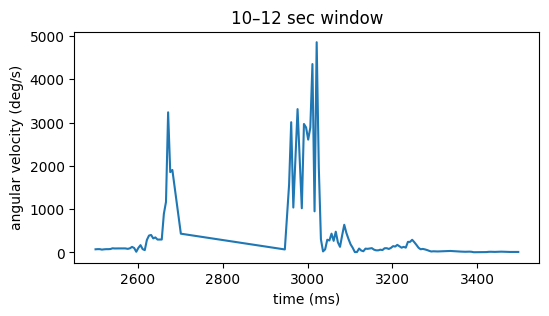

In [87]:
sub = df_clean[
    (df_clean["condition_number"] == 2) &
    (df_clean["trial_number"] == 2) &
    (df_clean["time_ms"] >= 2500) &   # 10 sec
    (df_clean["time_ms"] <= 3500)     # 12 sec
].copy()

plt.figure(figsize=(6,3))
plt.plot(sub["time_ms"], sub["angular_velocity"])
plt.xlabel("time (ms)")
plt.ylabel("angular velocity (deg/s)")
plt.title("10–12 sec window")
plt.show()

In [ ]:
def get_time_window(df, cond, trial, t_start_ms, t_end_ms):
    return df[
        (df["condition_number"] == cond) &
        (df["trial_number"] == trial) &
        (df["time_ms"] >= t_start_ms) &
        (df["time_ms"] <= t_end_ms)
    ].copy()

In [60]:
dt = np.diff(sub["gaze_capture_time"])
print(dt.min())

4976500


In [60]:
norm_stats = df_clean["clean_gaze_forward_norm"].describe()

print(f"N = {int(norm_stats['count']):,}")
print(f"Mean norm = {norm_stats['mean']:.6f}")
print(f"SD = {norm_stats['std']:.2e}")
print(f"Min = {norm_stats['min']:.6f}")
print(f"Max = {norm_stats['max']:.6f}")


N = 202,969
Mean norm = 1.000000
SD = 7.02e-17
Min = 1.000000
Max = 1.000000


## Outliers

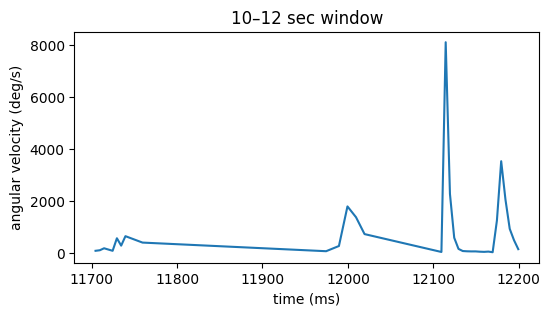

In [12]:
sub = df_clean[
    (df_clean["condition_number"] == 1) &
    (df_clean["trial_number"] == 1) &
    (df_clean["time_ms"] >= 11700) &   # 10 sec
    (df_clean["time_ms"] <= 12200)     # 12 sec
].copy()

plt.figure(figsize=(6,3))
plt.plot(sub["time_ms"], sub["angular_velocity"])
plt.xlabel("time (ms)")
plt.ylabel("angular velocity (deg/s)")
plt.title("10–12 sec window")
plt.show()

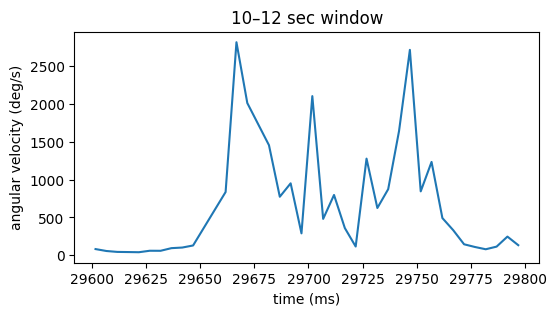

In [13]:
sub = df_clean[
    (df_clean["condition_number"] == 1) &
    (df_clean["trial_number"] == 4) &
    (df_clean["time_ms"] >= 29600) &   # 10 sec
    (df_clean["time_ms"] <= 29800)     # 12 sec
].copy()

plt.figure(figsize=(6,3))
plt.plot(sub["time_ms"], sub["angular_velocity"])
plt.xlabel("time (ms)")
plt.ylabel("angular velocity (deg/s)")
plt.title("10–12 sec window")
plt.show()

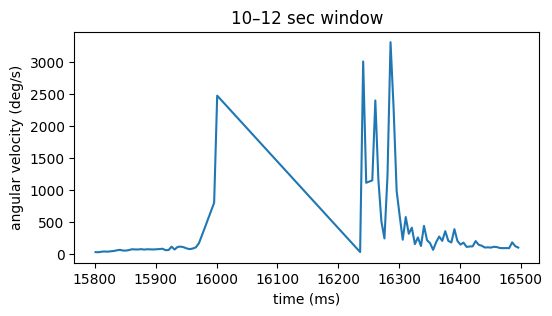

In [14]:
sub = df_clean[
    (df_clean["condition_number"] == 1) &
    (df_clean["trial_number"] == 4) &
    (df_clean["time_ms"] >= 15800) &   # 10 sec
    (df_clean["time_ms"] <= 16500)     # 12 sec
].copy()

plt.figure(figsize=(6,3))
plt.plot(sub["time_ms"], sub["angular_velocity"])
plt.xlabel("time (ms)")
plt.ylabel("angular velocity (deg/s)")
plt.title("10–12 sec window")
plt.show()

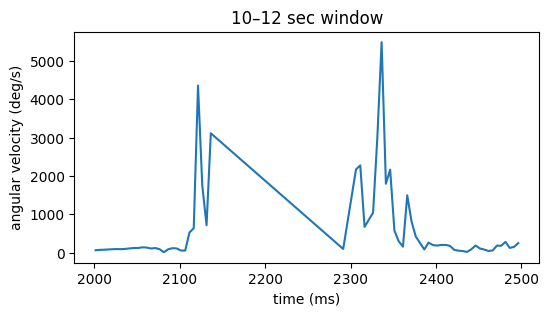

In [15]:
sub = df_clean[
    (df_clean["condition_number"] == 1) &
    (df_clean["trial_number"] == 2) &
    (df_clean["time_ms"] >= 2000) &   # 10 sec
    (df_clean["time_ms"] <= 2500)     # 12 sec
].copy()

plt.figure(figsize=(6,3))
plt.plot(sub["time_ms"], sub["angular_velocity"])
plt.xlabel("time (ms)")
plt.ylabel("angular velocity (deg/s)")
plt.title("10–12 sec window")
plt.show()

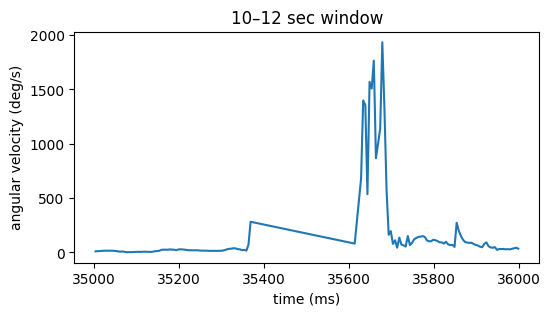

In [16]:
sub = df_clean[
    (df_clean["condition_number"] == 3) &
    (df_clean["trial_number"] == 5) &
    (df_clean["time_ms"] >= 35000) &   # 10 sec
    (df_clean["time_ms"] <= 36000)     # 12 sec
].copy()

plt.figure(figsize=(6,3))
plt.plot(sub["time_ms"], sub["angular_velocity"])
plt.xlabel("time (ms)")
plt.ylabel("angular velocity (deg/s)")
plt.title("10–12 sec window")
plt.show()

In [10]:
def add_angular_velocity_transcorr(df, time_col="gaze_capture_time"):
    """
    Add Debora-style angular velocity (deg/s) adapted for Varjo data.

    Uses:
    - gaze_origin_* and gaze_forward_* from Varjo
    - focus_distance
    - hmd_position_* and hmd_rotation_* to move from head coordinates to world coordinates

    Returns a copy of df with a new column:
    - angular_vel_tc
    """
    import numpy as np
    import pandas as pd

    df = df.copy()

    # sort in experiment order
    df = df.sort_values(
        ["participant_id", "condition_number", "trial_number", time_col]
    )

    df["angular_vel_tc"] = np.nan

    def rotate_vecs_by_quat(v, q):
        """
        Rotate Nx3 vectors v by Nx4 quaternions q = [x, y, z, w].
        """
        q_xyz = q[:, :3]
        q_w = q[:, 3:4]

        # t = 2 * cross(q_xyz, v)
        t = 2.0 * np.cross(q_xyz, v)

        # v' = v + w*t + cross(q_xyz, t)
        return v + q_w * t + np.cross(q_xyz, t)

    group_cols = ["participant_id", "model_name"]

    for _, sub in df.groupby(group_cols, sort=False):
        idx = sub.index

        # local gaze origin (head-relative)
        origin_local = sub[
            ["gaze_origin_x", "gaze_origin_y", "gaze_origin_z"]
        ].to_numpy(dtype=float)

        # local gaze forward (head-relative)
        forward_local = sub[
            ["gaze_forward_x", "gaze_forward_y", "gaze_forward_z"]
        ].to_numpy(dtype=float)

        # normalize forward
        forward_norm = np.linalg.norm(forward_local, axis=1, keepdims=True)
        forward_local = forward_local / np.clip(forward_norm, 1e-12, None)

        # HMD world pose
        hmd_pos = sub[
            ["hmd_position_x", "hmd_position_y", "hmd_position_z"]
        ].to_numpy(dtype=float)

        quat = sub[
            ["hmd_rotation_x", "hmd_rotation_y", "hmd_rotation_z", "hmd_rotation_w"]
        ].to_numpy(dtype=float)

        # rotate local gaze origin/forward into world coordinates
        origin_world = rotate_vecs_by_quat(origin_local, quat) + hmd_pos
        forward_world = rotate_vecs_by_quat(forward_local, quat)

        # normalize again after rotation
        forward_world = forward_world / np.clip(
            np.linalg.norm(forward_world, axis=1, keepdims=True), 1e-12, None
        )

        # reconstruct hitpoint like hpoo
        dist = sub["focus_distance"].to_numpy(dtype=float).reshape(-1, 1)
        hit_world = origin_world + dist * forward_world

        # Δh = consecutive hitpoint displacement
        delta_h = np.full_like(hit_world, np.nan)
        delta_h[1:] = hit_world[1:] - hit_world[:-1]

        # gaze direction g(t)
        gaze_vec = hit_world - origin_world
        gaze_vec = gaze_vec / np.clip(
            np.linalg.norm(gaze_vec, axis=1, keepdims=True), 1e-12, None
        )

        # remove component along gaze direction
        proj_scalar = np.sum(delta_h * gaze_vec, axis=1, keepdims=True)
        proj_vec = proj_scalar * gaze_vec
        delta_h_perp = delta_h - proj_vec

        v_gaze_inplane = np.linalg.norm(delta_h_perp, axis=1)

        # eye-to-hitpoint distance
        sub_hpoo = np.linalg.norm(hit_world - origin_world, axis=1)

        # angle in radians
        theta = np.arctan2(v_gaze_inplane, sub_hpoo)

        # dt in seconds
        t = sub[time_col].to_numpy(dtype=np.int64)
        dt = np.full(len(sub), np.nan)
        dt[1:] = np.diff(t) * 1e-9

        # angular velocity in deg/s
        vel = np.full(len(sub), np.nan)
        valid = (dt > 0) & np.isfinite(theta)
        vel[valid] = np.degrees(theta[valid] / dt[valid])

        df.loc[idx, "angular_vel_tc"] = vel

    return df

In [11]:
df_clean = add_angular_velocity_transcorr(df_clean, time_col="gaze_capture_time")

In [12]:
df_clean

,gaze_capture_time,raw_timestamp,relative_to_unix_epoch_timestamp,focus_distance,frame_number,stability,status,gaze_forward_x,gaze_forward_y,gaze_forward_z,...,object_position_x,object_position_y,object_position_z,object_rotation_x,object_rotation_y,object_rotation_z,object_rotation_w,participant_id,time_ms,angular_vel_tc
44844,1000325694741666500,1773141240816,336.4777,0.975025,584492,0.821958,Valid,0.013115,0.144055,0.989483,...,3.25,1.520,-0.11,0.0,-0.707107,0.0,0.707107,02,0.0000,NaN
44845,1000325694746666700,1773141240816,336.4777,0.977628,584493,0.817059,Valid,0.013078,0.144172,0.989466,...,3.25,1.520,-0.11,0.0,-0.707107,0.0,0.707107,02,5.0002,1.416867
44846,1000325694751663700,1773141240816,336.4777,0.980051,584494,0.827888,Valid,0.013039,0.144279,0.989451,...,3.25,1.520,-0.11,0.0,-0.707107,0.0,0.707107,02,9.9972,1.304523
44847,1000325694756664500,1773141240816,336.4777,0.982777,584495,0.820999,Valid,0.013003,0.144336,0.989443,...,3.25,1.520,-0.11,0.0,-0.707107,0.0,0.707107,02,14.9980,0.789465
44848,1000325694761666200,1773141240824,336.4866,0.985244,584496,0.822582,Valid,0.012964,0.144379,0.989437,...,3.25,1.520,-0.11,0.0,-0.707107,0.0,0.707107,02,19.9997,3.224694
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
381611,1000328169625686100,1773143715702,1593.0000,0.677271,1079278,0.281021,Valid,0.285666,-0.076886,0.955240,...,0.75,0.975,-0.70,0.0,0.000000,0.0,1.000000,02,97592.3892,37.132585
381612,1000328169630684400,1773143715702,1593.0000,0.681785,1079279,0.310471,Valid,0.287534,-0.074987,0.954831,...,0.75,0.975,-0.70,0.0,0.000000,0.0,1.000000,02,97597.3875,30.682067
381613,1000328169635683800,1773143715702,1593.0000,0.681963,1079280,0.328037,Valid,0.288786,-0.073097,0.954599,...,0.75,0.975,-0.70,0.0,0.000000,0.0,1.000000,02,97602.3869,26.117603
381614,1000328169640683200,1773143715702,1593.0000,0.681368,1079281,0.382888,Valid,0.289915,-0.071516,0.954377,...,0.75,0.975,-0.70,0.0,0.000000,0.0,1.000000,02,97607.3863,22.426189


## For the LEGO_analysis notebook

In [ ]:
cond = 1
trial = 0

sub = df[
    (df["condition_number"] == cond) &
    (df["trial_number"] == trial) &
    (df["time_ms"]  > 182200) &
    (df["time_ms"]  < 182500)
].copy()

sub["angular_velocity"] = pd.to_numeric(sub["angular_velocity"], errors="coerce")
sub["time_ms"] = pd.to_numeric(sub["time_ms"], errors="coerce")

vel_all = pd.to_numeric(df["angular_velocity"], errors="coerce")
vel_all = vel_all[np.isfinite(vel_all)]

global_mad_threshold, global_trace = at_mad_threshold(vel_all, th_0=200.0)

plt.figure(figsize=(10, 4))
plt.plot(sub["time_ms"], sub["angular_velocity"], lw=1.2, color="steelblue")
plt.axhline(
    global_mad_threshold,
    color="crimson",
    ls="--",
    lw=2,
    label=f"Global MAD threshold = {global_mad_threshold:.2f}"
)

plt.xlabel("Time (ms)")
plt.ylabel("Angular velocity (deg/s)")
plt.title(f"Angular velocity with global MAD threshold: Condition {cond}, Trial {trial}")
plt.legend()
plt.tight_layout()
plt.show()

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

vel = pd.to_numeric(df["angular_velocity"], errors="coerce")
vel = vel[np.isfinite(vel)]

global_mad_threshold, global_trace = at_mad_threshold(vel, th_0=200.0)

plt.figure(figsize=(8, 5))
plt.hist(vel, bins=200, color="steelblue", alpha=0.85)
plt.yscale("log")

plt.axvline(
    global_mad_threshold,
    color="crimson",
    linestyle="--",
    linewidth=2,
    label=f"Global MAD threshold = {global_mad_threshold:.1f} deg/s"
)

plt.xlabel("Angular velocity (deg/s)")
plt.ylabel("Count (log)")
plt.title("Angular velocity distribution with global MAD threshold")
plt.legend()
plt.tight_layout()
plt.show()
